# DualBranchSER — Exploratory Data Analysis & Preprocessing

**SJSU DATA 255 Deep Learning · Group 2 · April 2026**

**Team Contribution:** Data & Feature Engineering (Abhinita Sanabada)

## Overview
This notebook covers the EDA and preprocessing pipeline for the DualBranchSER project:
- Dataset scanning and label mapping (IEMOCAP + MELD)
- Class distribution analysis
- Audio duration distribution
- Feature extraction: Log-Mel Spectrogram + MFCC
- DataLoader preparation for model training

## Datasets
- **IEMOCAP**: 12-hour dyadic conversational speech · 4-class subset (angry, happy, sad, neutral)
- **MELD**: Friends TV show · real-world noisy conditions · used for cross-domain generalization

## Key Findings
- IEMOCAP: 16,266 shared-label rows · MELD: 10,494 shared-label rows
- Class imbalance identified → addressed in training with Focal Loss
- Audio duration: most utterances 2–8 seconds → fixed-length padding at 6s
- Feature input shape: (1, 124, 376) = 64 Log-Mel + 60 MFCC channels

## Note
Developed on Google Colab with datasets on Google Drive.
Replace `BASE_ROOT` with your local dataset path to run locally.


- **Notebook flow:** split into small, clear cells for setup, extraction, scanning, EDA, feature extraction, and dataloaders.

- **Dataset usage:** **IEMOCAP** is the main dataset for speech emotion classification, **MELD** is used for conversational emotion/context modeling, and **CASE** is used for continuous emotion change over time. :contentReference[oaicite:0]{index=0}

- **EDA covered:** label distribution, file/metadata checks, audio duration review, and CASE annotation-table/trajectory inspection.

- **Features covered:** **log-Mel spectrogram + MFCC** extraction is applied to the speech datasets (**IEMOCAP** and **MELD**).

- **Dataloaders covered:** utterance-level loaders for classification, **MELD** dialogue-context loaders for temporal context, and **CASE** sliding-window sequence loaders for continuous targets. :contentReference[oaicite:1]{index=1}

- **Temporal support:** **MELD** supports temporal context through ordered multi-party dialogues, and **CASE** supports it most directly through continuous valence/arousal annotations over time; **IEMOCAP** provides interaction context but is mainly used utterance-wise. :contentReference[oaicite:2]{index=2}

In [ ]:
!pip -q install librosa soundfile scikit-learn


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from pathlib import Path
import warnings
import random
import re
import json
import os
import tarfile
import zipfile
import subprocess
import urllib.request
import hashlib
import ast

import numpy as np
import pandas as pd
import soundfile as sf
import matplotlib.pyplot as plt
import librosa
import librosa.display

from IPython.display import display
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


In [ ]:
BASE_ROOT = Path('/content/drive/MyDrive/DeepLearningProject/Dataset')
BASE_ROOT.mkdir(parents=True, exist_ok=True)

IEMOCAP_ARCHIVE = BASE_ROOT / 'IEMOCAP_full_release_withoutVideos.tar.gz'
MELD_ARCHIVE = BASE_ROOT / 'MELD.Raw.tar.gz'
CASE_ARCHIVE = BASE_ROOT / 'CASE_full.zip'

MELD_LABEL_DIR = BASE_ROOT / 'MELD_label_csvs'
AUDIO_CACHE_ROOT = BASE_ROOT / '_audio_cache'
AUDIO_CACHE_ROOT.mkdir(parents=True, exist_ok=True)

AUTO_EXTRACT_ARCHIVES = True
ALLOW_MELD_CSV_DOWNLOAD = True

print('BASE_ROOT:', BASE_ROOT)
print('IEMOCAP archive exists:', IEMOCAP_ARCHIVE.exists())
print('MELD archive exists   :', MELD_ARCHIVE.exists())
print('CASE archive exists   :', CASE_ARCHIVE.exists())


BASE_ROOT: /content/drive/MyDrive/DeepLearningProject/Dataset
IEMOCAP archive exists: True
MELD archive exists   : True
CASE archive exists   : True


In [ ]:
def strip_archive_suffix(name: str) -> str:
    lower = name.lower()
    if lower.endswith('.tar.gz'):
        return name[:-7]
    if lower.endswith('.tgz'):
        return name[:-4]
    if lower.endswith('.zip'):
        return name[:-4]
    return Path(name).stem


def safe_extract_archive(archive_path: Path, target_dir: Path) -> Path:
    archive_path = Path(archive_path)
    target_dir = Path(target_dir)
    target_dir.mkdir(parents=True, exist_ok=True)
    if any(target_dir.iterdir()):
        print('Already extracted:', target_dir)
        return target_dir

    print(f'Extracting: {archive_path.name} -> {target_dir}')
    if archive_path.name.lower().endswith('.zip'):
        with zipfile.ZipFile(archive_path, 'r') as zf:
            zf.extractall(target_dir)
    else:
        with tarfile.open(archive_path, 'r:*') as tf:
            tf.extractall(target_dir)
    return target_dir


In [ ]:
def ensure_iemocap_ready() -> Path:
    # Define the expected final content root path
    expected_content_root = BASE_ROOT / 'IEMOCAP_full_release_withoutVideos' / 'IEMOCAP_full_release'

    # Check if the expected content root already exists and is not empty
    if expected_content_root.exists() and any(expected_content_root.iterdir()):
        print(f'Found existing IEMOCAP content root: {expected_content_root}')
        return expected_content_root

    # If not found, ensure the archive exists
    if not IEMOCAP_ARCHIVE.exists():
        raise FileNotFoundError(f'IEMOCAP archive not found at {IEMOCAP_ARCHIVE}')

    # Extract the archive to its parent directory
    extracted_parent_dir = safe_extract_archive(IEMOCAP_ARCHIVE, BASE_ROOT / strip_archive_suffix(IEMOCAP_ARCHIVE.name))

    # After extraction, the actual data is typically within a subfolder named 'IEMOCAP_full_release'
    final_content_root = extracted_parent_dir / 'IEMOCAP_full_release'
    if final_content_root.exists() and any(final_content_root.iterdir()):
        print(f'Extracted and resolved IEMOCAP content root: {final_content_root}')
        return final_content_root

    # Fallback if the 'IEMOCAP_full_release' subfolder structure is different
    if extracted_parent_dir.exists() and any(extracted_parent_dir.iterdir()):
        print(f'Warning: Could not find "IEMOCAP_full_release" subfolder. Using extracted parent as root: {extracted_parent_dir}')
        return extracted_parent_dir

    raise FileNotFoundError(f'IEMOCAP content root could not be resolved after extraction in {extracted_parent_dir}.')

iemocap_root = ensure_iemocap_ready()
print('Resolved IEMOCAP root:', iemocap_root)

Found existing IEMOCAP content root: /content/drive/MyDrive/DeepLearningProject/Dataset/IEMOCAP_full_release_withoutVideos/IEMOCAP_full_release
Resolved IEMOCAP root: /content/drive/MyDrive/DeepLearningProject/Dataset/IEMOCAP_full_release_withoutVideos/IEMOCAP_full_release


In [ ]:
MELD_CSV_URLS = {
    'train': 'https://raw.githubusercontent.com/declare-lab/MELD/master/data/MELD/train_sent_emo.csv',
    'dev': 'https://raw.githubusercontent.com/declare-lab/MELD/master/data/MELD/dev_sent_emo.csv',
    'test': 'https://raw.githubusercontent.com/declare-lab/MELD/master/data/MELD/test_sent_emo.csv',
}


def ensure_meld_ready() -> Path:
    candidates = [
        BASE_ROOT / 'MELD.Raw',
        BASE_ROOT / 'MELD_Raw',
        BASE_ROOT / 'MELD',
    ]
    outer_root = next((p for p in candidates if p.exists()), None)

    if outer_root is None:
        if not MELD_ARCHIVE.exists():
            raise FileNotFoundError(f'MELD archive not found at {MELD_ARCHIVE}')
        outer_root = safe_extract_archive(MELD_ARCHIVE, BASE_ROOT / strip_archive_suffix(MELD_ARCHIVE.name))

    for split in ['train', 'dev', 'test']:
        split_target = outer_root / f'{split}_splits'
        if split_target.exists() and any(split_target.iterdir()):
            continue
        inner_candidates = list(outer_root.rglob(f'{split}.tar.gz')) + list(outer_root.rglob(f'{split}.tgz'))
        if inner_candidates:
            safe_extract_archive(inner_candidates[0], split_target)

    return outer_root


meld_root = ensure_meld_ready()
print('Resolved MELD root:', meld_root)


Resolved MELD root: /content/drive/MyDrive/DeepLearningProject/Dataset/MELD.Raw


In [ ]:
def ensure_meld_csvs(label_dir: Path) -> dict:
    label_dir.mkdir(parents=True, exist_ok=True)
    csv_paths = {}

    for split in ['train', 'dev', 'test']:
        local_candidates = [
            label_dir / f'{split}_sent_emo.csv',
            BASE_ROOT / f'{split}_sent_emo.csv',
        ]
        for found in list(meld_root.rglob(f'{split}_sent_emo.csv')):
            local_candidates.append(found)

        existing = next((p for p in local_candidates if p.exists()), None)
        if existing is not None:
            csv_paths[split] = existing
            continue

        if not ALLOW_MELD_CSV_DOWNLOAD:
            raise FileNotFoundError(f'MELD label CSV for split={split} not found locally.')

        target = label_dir / f'{split}_sent_emo.csv'
        urllib.request.urlretrieve(MELD_CSV_URLS[split], target)
        csv_paths[split] = target

    return csv_paths


meld_csv_paths = ensure_meld_csvs(MELD_LABEL_DIR)
print(meld_csv_paths)


{'train': PosixPath('/content/drive/MyDrive/DeepLearningProject/Dataset/MELD.Raw/train_splits/train_sent_emo.csv'), 'dev': PosixPath('/content/drive/MyDrive/DeepLearningProject/Dataset/MELD.Raw/MELD.Raw/dev_sent_emo.csv'), 'test': PosixPath('/content/drive/MyDrive/DeepLearningProject/Dataset/MELD.Raw/MELD.Raw/test_sent_emo.csv')}


In [ ]:
def ensure_case_ready() -> Path:
    candidates = [
        BASE_ROOT / 'CASE_full',
        BASE_ROOT / 'CASE',
        BASE_ROOT / 'case_full',
    ]
    for p in candidates:
        if p.exists():
            return p

    if not CASE_ARCHIVE.exists():
        raise FileNotFoundError(f'CASE archive not found at {CASE_ARCHIVE}')

    return safe_extract_archive(CASE_ARCHIVE, BASE_ROOT / strip_archive_suffix(CASE_ARCHIVE.name))


case_root = ensure_case_ready()
print('Resolved CASE root:', case_root)


Resolved CASE root: /content/drive/MyDrive/DeepLearningProject/Dataset/CASE_full


## Quick path check

The next cells scan each dataset separately. If one cell fails, you will know exactly which dataset stage needs attention.


In [ ]:
def preview_top_level(root: Path, max_items: int = 12):
    root = Path(root)
    items = sorted(root.iterdir(), key=lambda p: (p.is_file(), p.name.lower())) if root.exists() else []
    print('Root:', root)
    print('Exists:', root.exists())
    print('Top-level items:', len(items))
    for p in items[:max_items]:
        print(('DIR ' if p.is_dir() else 'FILE'), p.name)


preview_top_level(iemocap_root)
preview_top_level(meld_root)
preview_top_level(case_root)


Root: /content/drive/MyDrive/DeepLearningProject/Dataset/IEMOCAP_full_release_withoutVideos/IEMOCAP_full_release
Exists: True
Top-level items: 4
DIR  Session1
DIR  Session2
DIR  Session3
DIR  Session4
Root: /content/drive/MyDrive/DeepLearningProject/Dataset/MELD.Raw
Exists: True
Top-level items: 4
DIR  dev_splits
DIR  MELD.Raw
DIR  test_splits
DIR  train_splits
Root: /content/drive/MyDrive/DeepLearningProject/Dataset/CASE_full
Exists: True
Top-level items: 1
DIR  CASE_full


In [ ]:
from pathlib import Path

for sdir in session_dirs:
    emo_dir = sdir / "dialog" / "EmoEvaluation"
    wav_dir = sdir / "sentences" / "wav"
    emo_files = list(emo_dir.glob("*.txt")) if emo_dir.exists() else []
    wav_files = list(wav_dir.rglob("*.wav")) if wav_dir.exists() else []
    print(f"{sdir.name}: emo_txt={len(emo_files)}, wav={len(wav_files)}")

Session1: emo_txt=0, wav=1819
Session2: emo_txt=0, wav=1811
Session3: emo_txt=0, wav=2136
Session4: emo_txt=0, wav=0


In [ ]:
def audio_info(path: Path):
    path = Path(path)
    try:
        if path.suffix.lower() in {'.wav', '.flac', '.ogg'}:
            info = sf.info(str(path))
            return float(info.frames) / float(info.samplerate), int(info.samplerate), int(info.channels)

        cmd = [
            'ffprobe', '-v', 'error',
            '-show_entries', 'stream=sample_rate,channels:format=duration',
            '-of', 'json', str(path)
        ]
        out = subprocess.check_output(cmd, stderr=subprocess.STDOUT)
        data = json.loads(out.decode('utf-8'))
        duration = float(data.get('format', {}).get('duration', 0.0))
        sr = None
        channels = None
        for stream in data.get('streams', []):
            sr_val = stream.get('sample_rate')
            ch_val = stream.get('channels')
            if sr is None and sr_val is not None:
                sr = int(sr_val)
            if channels is None and ch_val is not None:
                channels = int(ch_val)
        return duration, sr or 16000, channels or 1
    except Exception:
        return None


def cached_audio_path_for_media(path: Path, target_sr: int = 16000) -> Path:
    digest = hashlib.md5(str(path).encode('utf-8')).hexdigest()[:16]
    safe_stem = re.sub(r'[^A-Za-z0-9_.-]+', '_', path.stem)[:60]
    return AUDIO_CACHE_ROOT / f'{safe_stem}_{digest}_{target_sr}.wav'


def ensure_audio_wav(path: Path, target_sr: int = 16000) -> Path:
    path = Path(path)
    if path.suffix.lower() == '.wav':
        return path
    cached = cached_audio_path_for_media(path, target_sr)
    if cached.exists():
        return cached
    cmd = ['ffmpeg', '-y', '-i', str(path), '-vn', '-ac', '1', '-ar', str(target_sr), str(cached)]
    subprocess.run(cmd, check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    return cached


def standardize_2d(x):
    x = np.asarray(x, dtype=np.float32)
    mu = x.mean()
    sigma = x.std()
    return (x - mu) / (sigma + 1e-6)


def normalize_emotion_name(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return None
    x = str(x).strip().lower()
    alias_map = {
        'anger': 'angry',
        'ang': 'angry',
        'joy': 'happy',
        'happiness': 'happy',
        'excited': 'happy',
        'exc': 'happy',
        'sadness': 'sad',
        'fearful': 'fear',
        'surprised': 'surprise',
        'frustration': 'frustration',
    }
    return alias_map.get(x, x)


## IEMOCAP scan and EDA

This section is only for **IEMOCAP**. It builds utterance-level metadata from the evaluation text files and aligned `.wav` files.


In [ ]:
IEMOCAP_EMO = {
    'ang': 'angry', 'hap': 'happy', 'exc': 'happy', 'sad': 'sad',
    'neu': 'neutral', 'fru': 'frustration', 'fea': 'fear',
    'sur': 'surprise', 'oth': 'other', 'xxx': 'other'
}


def parse_iemocap_eval_file(txt_path: Path) -> pd.DataFrame:
    rows = []
    pattern = re.compile(r'^\[(?P<start>[0-9.]+)\s-\s(?P<end>[0-9.]+)\]\s+(?P<utt>\S+)\s+(?P<label>\S+)')
    for line in txt_path.read_text(errors='ignore').splitlines():
        m = pattern.match(line.strip())
        if not m:
            continue
        utt = m.group('utt')
        raw = m.group('label').lower()
        emo = IEMOCAP_EMO.get(raw, raw)
        rows.append({
            'utt_id': utt,
            'primary_emotion': emo,
            'start_sec': float(m.group('start')),
            'end_sec': float(m.group('end')),
            'eval_file': str(txt_path),
        })
    return pd.DataFrame(rows)


def scan_iemocap(root: Path) -> pd.DataFrame:
    eval_files = sorted(root.rglob('Session*/dialog/EmoEvaluation/Categorical/*_cat.txt'))
    if not eval_files:
        eval_files = sorted(root.rglob('Session*/dialog/EmoEvaluation/*.txt'))
    if not eval_files:
        raise FileNotFoundError(f'No IEMOCAP evaluation files found within {root}.')

    print("IEMOCAP eval files found:", len(eval_files))
    for p in eval_files[:5]:
        print(p)

    eval_df = pd.concat([parse_iemocap_eval_file(p) for p in eval_files], ignore_index=True)
    wav_map = {wav.stem: wav for wav in root.rglob('sentences/wav/*/*.wav')}

    rows = []
    for _, row in eval_df.iterrows():
        wav = wav_map.get(row['utt_id'])
        if wav is None:
            continue
        info = audio_info(wav)
        if info is None:
            continue
        duration, sr, channels = info
        session = row['utt_id'].split('_')[0][:5]
        speaker_match = re.match(r'(Ses\d\d[FM])_', row['utt_id'])
        speaker = speaker_match.group(1) if speaker_match else row['utt_id'].split('_')[0]
        rows.append({
            'dataset': 'IEMOCAP',
            'path': str(wav),
            'file_id': wav.name,
            'session': session,
            'speaker': speaker,
            'primary_emotion': normalize_emotion_name(row['primary_emotion']),
            'duration_sec': duration,
            'sr': sr,
            'channels': channels,
            'start_sec': row['start_sec'],
            'end_sec': row['end_sec'],
        })
    return pd.DataFrame(rows)


In [ ]:
iemocap_meta = scan_iemocap(iemocap_root)
print('IEMOCAP rows:', iemocap_meta.shape)
display(iemocap_meta.head())


IEMOCAP rows: (17298, 11)


,dataset,path,file_id,session,speaker,primary_emotion,duration_sec,sr,channels,start_sec,end_sec
0,IEMOCAP,/content/drive/MyDrive/DeepLearningProject/Dat...,Ses01F_impro01_F000.wav,Ses01,Ses01F,neutral state,1.945563,16000,1,0.0,0.0
1,IEMOCAP,/content/drive/MyDrive/DeepLearningProject/Dat...,Ses01F_impro01_F001.wav,Ses01,Ses01F,neutral state,1.382437,16000,1,0.0,0.0
2,IEMOCAP,/content/drive/MyDrive/DeepLearningProject/Dat...,Ses01F_impro01_F002.wav,Ses01,Ses01F,neutral state,3.130250,16000,1,0.0,0.0
3,IEMOCAP,/content/drive/MyDrive/DeepLearningProject/Dat...,Ses01F_impro01_F003.wav,Ses01,Ses01F,neutral state,1.497500,16000,1,0.0,0.0
4,IEMOCAP,/content/drive/MyDrive/DeepLearningProject/Dat...,Ses01F_impro01_F004.wav,Ses01,Ses01F,neutral state,3.414250,16000,1,0.0,0.0


In [ ]:
emo_eval_dir = iemocap_root / 'Session1' / 'dialog' / 'EmoEvaluation'
print(f"Files directly in {emo_eval_dir.name}:")
if emo_eval_dir.exists():
    main_txts = list(emo_eval_dir.glob('*.txt'))
    for p in main_txts[:5]:
        print('  FILE', p.name)
    if main_txts:
        print('\nSample from main merged file:', main_txts[0].name)
        print('-' * 40)
        print('\n'.join(main_txts[0].read_text(errors='ignore').splitlines()[:5]))
        print('-' * 40)

cat_files = list(iemocap_root.rglob('Session*/dialog/EmoEvaluation/Categorical/*.txt'))
if cat_files:
    print('\nSample from Categorical file:', cat_files[0].name)
    print('-' * 40)
    print('\n'.join(cat_files[0].read_text(errors='ignore').splitlines()[:5]))
    print('-' * 40)


Files directly in EmoEvaluation:

Sample from Categorical file: Ses01M_script01_2_e4_cat.txt
----------------------------------------
Ses01M_script01_2_F000 :Other; (annoyed)
Ses01M_script01_2_F001 :Other; (annoyed)
Ses01M_script01_2_F002 :Other; (annoyed)
Ses01M_script01_2_F003 :Other; (annoyed)
Ses01M_script01_2_F004 :Anger; ()
----------------------------------------


In [ ]:
categorical_path = iemocap_root / 'Session1' / 'dialog' / 'EmoEvaluation' / 'Categorical'
print(f"DEBUG: Contents of '{categorical_path.name}':")
if categorical_path.exists():
    for item in sorted(categorical_path.iterdir()):
        print(f"  {'DIR ' if item.is_dir() else 'FILE'} {item.name}")
else:
    print(f"  Path does not exist: {categorical_path}")

DEBUG: Contents of 'Categorical':
  FILE Ses01F_impro01_e2.anvil
  FILE Ses01F_impro01_e2_cat.txt
  FILE Ses01F_impro01_e3.anvil
  FILE Ses01F_impro01_e3_cat.txt
  FILE Ses01F_impro01_e4.anvil
  FILE Ses01F_impro01_e4_cat.txt
  FILE Ses01F_impro02_e1.anvil
  FILE Ses01F_impro02_e1_cat.txt
  FILE Ses01F_impro02_e3.anvil
  FILE Ses01F_impro02_e3_cat.txt
  FILE Ses01F_impro02_e4.anvil
  FILE Ses01F_impro02_e4_cat.txt
  FILE Ses01F_impro03_e1.anvil
  FILE Ses01F_impro03_e1_cat.txt
  FILE Ses01F_impro03_e2.anvil
  FILE Ses01F_impro03_e2_cat.txt
  FILE Ses01F_impro03_e4.anvil
  FILE Ses01F_impro03_e4_cat.txt
  FILE Ses01F_impro04_e1.anvil
  FILE Ses01F_impro04_e1_cat.txt
  FILE Ses01F_impro04_e2.anvil
  FILE Ses01F_impro04_e2_cat.txt
  FILE Ses01F_impro04_e4.anvil
  FILE Ses01F_impro04_e4_cat.txt
  FILE Ses01F_impro05_e1.anvil
  FILE Ses01F_impro05_e1_cat.txt
  FILE Ses01F_impro05_e3.anvil
  FILE Ses01F_impro05_e3_cat.txt
  FILE Ses01F_impro05_e4.anvil
  FILE Ses01F_impro05_e4_cat.txt
  FILE

IEMOCAP emotion counts:


,emotion,count
0,frustration,4039
1,happy,3980
2,neutral state,3843
3,sad,2225
4,angry,2179
5,other,452
6,surprise,376
7,fear,137
8,disgust,67


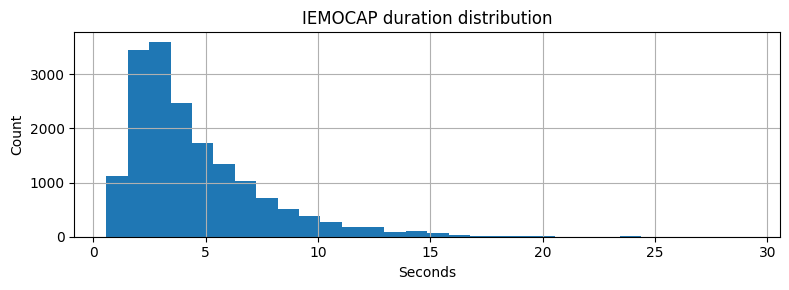

In [ ]:
print('IEMOCAP emotion counts:')
display(iemocap_meta['primary_emotion'].value_counts().rename_axis('emotion').reset_index(name='count'))

plt.figure(figsize=(8, 3))
iemocap_meta['duration_sec'].hist(bins=30)
plt.title('IEMOCAP duration distribution')
plt.xlabel('Seconds')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


## MELD scan and EDA

This section is only for **MELD**. It builds utterance-level metadata from the official split CSV files and links each row to the matching media file.


In [ ]:
def find_split_media_root(meld_root: Path, split_name: str) -> Path:
    candidates = [
        meld_root / f'{split_name}_splits',
        meld_root / split_name,
        meld_root / f'{split_name}_sents',
    ]
    for c in candidates:
        if c.exists():
            return c
    raise FileNotFoundError(f'Could not find MELD media folder for split={split_name}')


def build_meld_media_index(media_root: Path) -> dict:
    index = {}
    pattern = re.compile(r'dia(\d+)_utt(\d+)', re.IGNORECASE)
    media_files = list(media_root.rglob('*.mp4')) + list(media_root.rglob('*.wav')) + list(media_root.rglob('*.m4a'))
    for p in media_files:
        m = pattern.search(p.stem)
        if m:
            index[(int(m.group(1)), int(m.group(2)))] = p
    return index


def detect_col(df: pd.DataFrame, candidates):
    lower_map = {str(c).strip().lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in lower_map:
            return lower_map[c.lower()]
    return None


def scan_meld(meld_root: Path, csv_paths: dict) -> pd.DataFrame:
    frames = []
    for split_name, csv_path in csv_paths.items():
        media_root = find_split_media_root(meld_root, split_name)
        media_index = build_meld_media_index(media_root)
        df = pd.read_csv(csv_path)

        dia_col = detect_col(df, ['Dialogue_ID', 'dialogue_id'])
        utt_col = detect_col(df, ['Utterance_ID', 'utterance_id'])
        emo_col = detect_col(df, ['Emotion', 'emotion'])
        speaker_col = detect_col(df, ['Speaker', 'speaker'])
        utt_text_col = detect_col(df, ['Utterance', 'utterance'])

        rows = []
        for _, row in df.iterrows():
            dia = int(row[dia_col])
            utt = int(row[utt_col])
            media_path = media_index.get((dia, utt))
            if media_path is None:
                continue
            info = audio_info(media_path)
            if info is None:
                continue
            duration, sr, channels = info
            rows.append({
                'dataset': 'MELD',
                'path': str(media_path),
                'file_id': media_path.name,
                'dialogue_id': dia,
                'utterance_id': utt,
                'speaker': str(row[speaker_col]) if speaker_col is not None else f'MELD_{dia}',
                'utterance_text': str(row[utt_text_col]) if utt_text_col is not None else '',
                'primary_emotion': normalize_emotion_name(row[emo_col]),
                'duration_sec': duration,
                'sr': sr,
                'channels': channels,
                'predefined_split': split_name,
            })
        frames.append(pd.DataFrame(rows))
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


In [ ]:
meld_meta = scan_meld(meld_root, meld_csv_paths)
print('MELD rows:', meld_meta.shape)
display(meld_meta.head())


MELD rows: (12696, 12)


,dataset,path,file_id,dialogue_id,utterance_id,speaker,utterance_text,primary_emotion,duration_sec,sr,channels,predefined_split
0,MELD,/content/drive/MyDrive/DeepLearningProject/Dat...,dia0_utt0.mp4,0,0,Chandler,also I was the point person on my companys tr...,neutral,5.694,48000,2,train
1,MELD,/content/drive/MyDrive/DeepLearningProject/Dat...,dia0_utt1.mp4,0,1,The Interviewer,You mustve had your hands full.,neutral,1.502,48000,2,train
2,MELD,/content/drive/MyDrive/DeepLearningProject/Dat...,dia0_utt2.mp4,0,2,Chandler,That I did. That I did.,neutral,2.947,48000,2,train
3,MELD,/content/drive/MyDrive/DeepLearningProject/Dat...,dia0_utt3.mp4,0,3,The Interviewer,So lets talk a little bit about your duties.,neutral,2.774,48000,2,train
4,MELD,/content/drive/MyDrive/DeepLearningProject/Dat...,dia0_utt4.mp4,0,4,Chandler,My duties? All right.,surprise,6.487,48000,2,train


MELD emotion counts:


,emotion,count
0,neutral,5952
1,happy,2154
2,surprise,1532
3,angry,1477
4,sad,911
5,fear,335
6,disgust,335


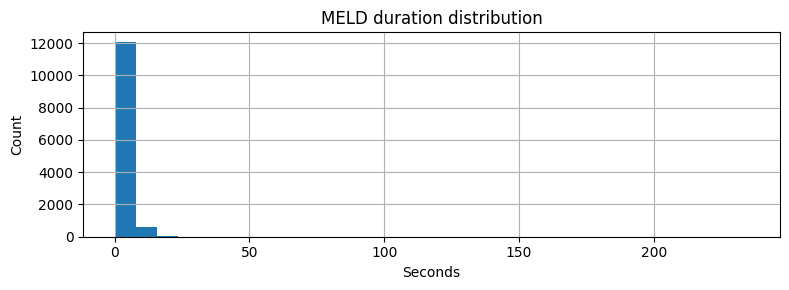

In [ ]:
print('MELD emotion counts:')
display(meld_meta['primary_emotion'].value_counts().rename_axis('emotion').reset_index(name='count'))

plt.figure(figsize=(8, 3))
meld_meta['duration_sec'].hist(bins=30)
plt.title('MELD duration distribution')
plt.xlabel('Seconds')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


## Shared classification label space

For the speech classifier we use a clean shared **4-class** label space:
`angry`, `happy`, `sad`, `neutral`

- **IEMOCAP** is the main training source.
- **MELD** is the external/generalization evaluation source.
- **CASE** stays separate for continuous temporal modeling.


In [ ]:
SHARED_LABELS = ['angry', 'happy', 'sad', 'neutral']
LABEL_TO_IDX = {name: i for i, name in enumerate(SHARED_LABELS)}
IDX_TO_LABEL = {i: name for name, i in LABEL_TO_IDX.items()}

IEMOCAP_TO_SHARED = {
    'angry': 'angry',
    'frustration': 'angry',
    'happy': 'happy',
    'happiness': 'happy',
    'excited': 'happy',
    'excitement': 'happy',
    'sad': 'sad',
    'sadness': 'sad',
    'neutral': 'neutral',
    'neutral state': 'neutral',
}

MELD_TO_SHARED = {
    'angry': 'angry',
    'happy': 'happy',
    'joy': 'happy',
    'sad': 'sad',
    'sadness': 'sad',
    'neutral': 'neutral',
}

iemocap_meta['shared_emotion'] = iemocap_meta['primary_emotion'].map(IEMOCAP_TO_SHARED)
meld_meta['shared_emotion'] = meld_meta['primary_emotion'].map(MELD_TO_SHARED)

iemocap_cls = iemocap_meta.dropna(subset=['shared_emotion']).copy().reset_index(drop=True)
meld_cls = meld_meta.dropna(subset=['shared_emotion']).copy().reset_index(drop=True)

iemocap_cls['target_idx'] = iemocap_cls['shared_emotion'].map(LABEL_TO_IDX).astype(int)
meld_cls['target_idx'] = meld_cls['shared_emotion'].map(LABEL_TO_IDX).astype(int)

iemocap_cls['soft_target'] = iemocap_cls['target_idx'].apply(
    lambda i: np.eye(len(SHARED_LABELS), dtype=np.float32)[i]
)
meld_cls['soft_target'] = meld_cls['target_idx'].apply(
    lambda i: np.eye(len(SHARED_LABELS), dtype=np.float32)[i]
)

print('IEMOCAP shared rows:', len(iemocap_cls))
print('MELD shared rows   :', len(meld_cls))
print('Label mapping      :', LABEL_TO_IDX)

IEMOCAP shared rows: 16266
MELD shared rows   : 10494
Label mapping      : {'angry': 0, 'happy': 1, 'sad': 2, 'neutral': 3}


In [ ]:
import re
import pandas as pd

def normalize_iemocap_session(x):
    if pd.isna(x):
        return x
    x = str(x).strip()
    m = re.search(r'(\d+)', x)
    if not m:
        return x
    return f"Ses{int(m.group(1)):02d}"

iemocap_meta['session'] = iemocap_meta['session'].apply(normalize_iemocap_session)

print('Normalized IEMOCAP sessions:')
display(iemocap_meta['session'].value_counts().sort_index().rename_axis('session').reset_index(name='count'))

Normalized IEMOCAP sessions:


,session,count
0,Ses01,5457
1,Ses02,5433
2,Ses03,6408


In [ ]:
from pathlib import Path

print("IEMOCAP root:", iemocap_root)
session_dirs = sorted([p.name for p in Path(iemocap_root).iterdir() if p.is_dir()])
print("Top-level folders:")
print(session_dirs)

IEMOCAP root: /content/drive/MyDrive/DeepLearningProject/Dataset/IEMOCAP_full_release_withoutVideos/IEMOCAP_full_release
Top-level folders:
['Session1', 'Session2', 'Session3', 'Session4']


In [ ]:
from pathlib import Path
import re

session_dirs = sorted([p for p in Path(iemocap_root).iterdir() if p.is_dir() and p.name.startswith("Session")])
print("Detected session folders:", [p.name for p in session_dirs])

def session_folder_to_code(name):
    m = re.search(r"(\d+)", str(name))
    return f"Ses{int(m.group(1)):02d}" if m else None

Detected session folders: ['Session1', 'Session2', 'Session3', 'Session4']


In [ ]:
print('IEMOCAP sessions before shared-label filtering:')
display(iemocap_meta['session'].value_counts().sort_index().rename_axis('session').reset_index(name='count'))

print('IEMOCAP sessions after shared-label filtering:')
display(iemocap_cls['session'].value_counts().sort_index().rename_axis('session').reset_index(name='count'))

print('IEMOCAP shared emotion counts:')
display(iemocap_cls['shared_emotion'].value_counts().rename_axis('emotion').reset_index(name='count'))

IEMOCAP sessions before shared-label filtering:


,session,count
0,Ses01,5457
1,Ses02,5433
2,Ses03,6408


IEMOCAP sessions after shared-label filtering:


,session,count
0,Ses01,5032
1,Ses02,5164
2,Ses03,6070


IEMOCAP shared emotion counts:


,emotion,count
0,angry,6218
1,happy,3980
2,neutral,3843
3,sad,2225


In [ ]:
from pathlib import Path

for sdir in session_dirs:
    emo_cat_dir = sdir / "dialog" / "EmoEvaluation" / "Categorical"
    emo_files = list(emo_cat_dir.glob("*_cat.txt")) if emo_cat_dir.exists() else []
    wav_dir = sdir / "sentences" / "wav"
    wav_files = list(wav_dir.rglob("*.wav")) if wav_dir.exists() else []
    print(f"{sdir.name}: cat_txt={len(emo_files)}, wav={len(wav_files)}")

Session1: cat_txt=84, wav=1819
Session2: cat_txt=90, wav=1811
Session3: cat_txt=96, wav=2136
Session4: cat_txt=0, wav=0


In [ ]:
available_sessions = sorted(iemocap_cls["session"].dropna().unique().tolist())
print("Available sessions:", available_sessions)

from sklearn.model_selection import train_test_split

if "Ses05" in available_sessions:
    train_sessions = ["Ses01", "Ses02", "Ses03"]
    val_sessions = ["Ses04"]
    test_sessions = ["Ses05"]

    train_iemocap_df = iemocap_cls[iemocap_cls["session"].isin(train_sessions)].reset_index(drop=True)
    val_iemocap_df   = iemocap_cls[iemocap_cls["session"].isin(val_sessions)].reset_index(drop=True)
    test_iemocap_df  = iemocap_cls[iemocap_cls["session"].isin(test_sessions)].reset_index(drop=True)
    split_mode = "standard_5_session"

elif "Ses04" in available_sessions:
    train_sessions = ["Ses01", "Ses02"]
    val_sessions = ["Ses03"]
    test_sessions = ["Ses04"]

    train_iemocap_df = iemocap_cls[iemocap_cls["session"].isin(train_sessions)].reset_index(drop=True)
    val_iemocap_df   = iemocap_cls[iemocap_cls["session"].isin(val_sessions)].reset_index(drop=True)
    test_iemocap_df  = iemocap_cls[iemocap_cls["session"].isin(test_sessions)].reset_index(drop=True)
    split_mode = "fallback_4_session"

elif len(available_sessions) == 3:
    train_iemocap_df, temp_iemocap_df = train_test_split(
        iemocap_cls,
        test_size=0.20,
        random_state=42,
        stratify=iemocap_cls["shared_emotion"]
    )

    val_iemocap_df, test_iemocap_df = train_test_split(
        temp_iemocap_df,
        test_size=0.50,
        random_state=42,
        stratify=temp_iemocap_df["shared_emotion"]
    )

    train_iemocap_df = train_iemocap_df.reset_index(drop=True)
    val_iemocap_df   = val_iemocap_df.reset_index(drop=True)
    test_iemocap_df  = test_iemocap_df.reset_index(drop=True)
    split_mode = "fallback_3_session_random"

else:
    raise ValueError(f"Not enough IEMOCAP sessions for splitting. Found: {available_sessions}")

print("Split mode:", split_mode)
print("IEMOCAP train/val/test:", len(train_iemocap_df), len(val_iemocap_df), len(test_iemocap_df))

Available sessions: ['Ses01', 'Ses02', 'Ses03']
Split mode: fallback_3_session_random
IEMOCAP train/val/test: 13012 1627 1627


In [ ]:
print(train_iemocap_df["shared_emotion"].value_counts())
print(val_iemocap_df["shared_emotion"].value_counts())
print(test_iemocap_df["shared_emotion"].value_counts())

shared_emotion
angry      4974
happy      3184
neutral    3074
sad        1780
Name: count, dtype: int64
shared_emotion
angry      622
happy      398
neutral    385
sad        222
Name: count, dtype: int64
shared_emotion
angry      622
happy      398
neutral    384
sad        223
Name: count, dtype: int64


In [ ]:
available_sessions = sorted(iemocap_cls["session"].dropna().unique().tolist())
print("Available sessions:", available_sessions)

if "Ses04" in available_sessions and "Ses05" not in available_sessions:
    train_sessions = ["Ses01", "Ses02"]
    val_sessions = ["Ses03"]
    test_sessions = ["Ses04"]
else:
    train_sessions = ["Ses01", "Ses02", "Ses03"]
    val_sessions = ["Ses04"]
    test_sessions = ["Ses05"]

Available sessions: ['Ses01', 'Ses02', 'Ses03']


In [ ]:
# MELD official splits are preserved for evaluation and temporal context
meld_train_df = meld_cls[meld_cls['predefined_split'] == 'train'].reset_index(drop=True)
meld_dev_df = meld_cls[meld_cls['predefined_split'] == 'dev'].reset_index(drop=True)
meld_test_df = meld_cls[meld_cls['predefined_split'] == 'test'].reset_index(drop=True)

print('MELD train/dev/test:', len(meld_train_df), len(meld_dev_df), len(meld_test_df))


MELD train/dev/test: 8244 896 1354


In [ ]:
# Optional runtime limits for quick debugging
USE_SMALL_SANITY_SUBSET = True
SANITY_TRAIN_ROWS = 512
SANITY_EVAL_ROWS = 256


def maybe_limit(df: pd.DataFrame, max_rows: int | None):
    if max_rows is None or len(df) <= max_rows:
        return df.reset_index(drop=True)
    return df.sample(max_rows, random_state=SEED).reset_index(drop=True)


run_train_iemocap_df = maybe_limit(train_iemocap_df, SANITY_TRAIN_ROWS if USE_SMALL_SANITY_SUBSET else None)
run_val_iemocap_df = maybe_limit(val_iemocap_df, SANITY_EVAL_ROWS if USE_SMALL_SANITY_SUBSET else None)
run_test_iemocap_df = maybe_limit(test_iemocap_df, SANITY_EVAL_ROWS if USE_SMALL_SANITY_SUBSET else None)
run_meld_dev_df = maybe_limit(meld_dev_df, SANITY_EVAL_ROWS if USE_SMALL_SANITY_SUBSET else None)
run_meld_test_df = maybe_limit(meld_test_df, SANITY_EVAL_ROWS if USE_SMALL_SANITY_SUBSET else None)

print('Run sizes -> IEMOCAP train/val/test:', len(run_train_iemocap_df), len(run_val_iemocap_df), len(run_test_iemocap_df))
print('Run sizes -> MELD dev/test         :', len(run_meld_dev_df), len(run_meld_test_df))


Run sizes -> IEMOCAP train/val/test: 512 256 256
Run sizes -> MELD dev/test         : 256 256


## Mel spectrogram + MFCC feature extraction

This section is shared by **IEMOCAP** and **MELD** only.
CASE is not used here, because CASE is handled as a continuous temporal sequence task.


In [ ]:
TARGET_SR = 16000
MAX_SECONDS = 6.0
MAX_LEN = int(TARGET_SR * MAX_SECONDS)
N_MELS = 64
N_MFCC = 20
USE_MFCC_DELTAS = True
N_FFT = 1024
HOP_LENGTH = 256
BATCH_SIZE = 16
NUM_WORKERS = 0
FEATURE_MODE = 'both'   # 'logmel', 'mfcc', 'both'


In [ ]:
def load_audio_fixed(path, target_sr=TARGET_SR, max_len=MAX_LEN):
    wav_path = ensure_audio_wav(Path(path), target_sr=target_sr)
    y, sr = librosa.load(str(wav_path), sr=target_sr, mono=True)
    if len(y) < max_len:
        y = np.pad(y, (0, max_len - len(y)))
    else:
        y = y[:max_len]
    return y.astype(np.float32), sr


def wav_to_logmel(y, sr=TARGET_SR):
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return standardize_2d(mel_db)


def wav_to_mfcc(y, sr=TARGET_SR):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH)
    blocks = [mfcc]
    if USE_MFCC_DELTAS:
        blocks.append(librosa.feature.delta(mfcc))
        blocks.append(librosa.feature.delta(mfcc, order=2))
    stacked = np.concatenate(blocks, axis=0)
    return standardize_2d(stacked)


def extract_feature_image(path):
    y, sr = load_audio_fixed(path)
    if FEATURE_MODE == 'logmel':
        feat = wav_to_logmel(y, sr)
    elif FEATURE_MODE == 'mfcc':
        feat = wav_to_mfcc(y, sr)
    elif FEATURE_MODE == 'both':
        logmel = wav_to_logmel(y, sr)
        mfcc = wav_to_mfcc(y, sr)
        t = min(logmel.shape[1], mfcc.shape[1])
        feat = np.concatenate([logmel[:, :t], mfcc[:, :t]], axis=0)
    else:
        raise ValueError('FEATURE_MODE must be logmel, mfcc, or both')
    return feat.astype(np.float32)


In [ ]:
class SpeechEmotionDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        feat = extract_feature_image(row['path'])
        x = torch.tensor(feat, dtype=torch.float32).unsqueeze(0)
        hard_y = torch.tensor(int(row['target_idx']), dtype=torch.long)
        soft_y = torch.tensor(row['soft_target'], dtype=torch.float32)
        out = {
            'x': x,
            'hard_y': hard_y,
            'soft_y': soft_y,
            'label': row['shared_emotion'],
            'path': row['path'],
            'dataset': row['dataset'],
        }
        if 'dialogue_id' in row.index:
            out['dialogue_id'] = int(row['dialogue_id'])
            out['utterance_id'] = int(row['utterance_id'])
        if 'session' in row.index:
            out['session'] = row['session']
        return out


In [ ]:
train_iemocap_ds = SpeechEmotionDataset(run_train_iemocap_df)
val_iemocap_ds = SpeechEmotionDataset(run_val_iemocap_df)
test_iemocap_ds = SpeechEmotionDataset(run_test_iemocap_df)

train_iemocap_loader = DataLoader(train_iemocap_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_iemocap_loader = DataLoader(val_iemocap_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_iemocap_loader = DataLoader(test_iemocap_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

batch = next(iter(train_iemocap_loader))
print('IEMOCAP batch x shape:', batch['x'].shape)
print('IEMOCAP batch hard_y :', batch['hard_y'].shape)
print('FEATURE_MODE         :', FEATURE_MODE)


IEMOCAP batch x shape: torch.Size([16, 1, 124, 376])
IEMOCAP batch hard_y : torch.Size([16])
FEATURE_MODE         : both


In [ ]:
meld_dev_ds = SpeechEmotionDataset(run_meld_dev_df)
meld_test_ds = SpeechEmotionDataset(run_meld_test_df)

meld_dev_loader = DataLoader(meld_dev_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
meld_test_loader = DataLoader(meld_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

batch = next(iter(meld_dev_loader))
print('MELD batch x shape:', batch['x'].shape)
print('MELD batch hard_y :', batch['hard_y'].shape)


MELD batch x shape: torch.Size([16, 1, 124, 376])
MELD batch hard_y : torch.Size([16])


## MELD temporal dialogue-context dataloader

This loader is separate from the utterance classifier. It keeps a short history of earlier utterances from the same dialogue so you can show temporal emotion changes across turns.


In [ ]:
MELD_CONTEXT_SIZE = 3


def build_meld_context_rows(df, context_size=MELD_CONTEXT_SIZE):
    df = df.sort_values(['predefined_split', 'dialogue_id', 'utterance_id']).reset_index(drop=True)
    rows = []
    for (split_name, dialogue_id), g in df.groupby(['predefined_split', 'dialogue_id'], dropna=True):
        g = g.sort_values('utterance_id').reset_index(drop=True)
        records = g.to_dict('records')
        for i, rec in enumerate(records):
            hist = records[max(0, i - context_size):i]
            out = dict(rec)
            out['context_paths'] = [r['path'] for r in hist]
            out['context_emotions'] = [r['shared_emotion'] for r in hist]
            out['context_len'] = len(hist)
            rows.append(out)
    return pd.DataFrame(rows)


meld_context_df = build_meld_context_rows(meld_cls, context_size=MELD_CONTEXT_SIZE)
print('MELD context rows:', meld_context_df.shape)
display(meld_context_df[['predefined_split', 'dialogue_id', 'utterance_id', 'shared_emotion', 'context_len', 'context_emotions']].head())


MELD context rows: (10494, 18)


,predefined_split,dialogue_id,utterance_id,shared_emotion,context_len,context_emotions
0,dev,0,0,sad,0,[]
1,dev,1,0,neutral,0,[]
2,dev,1,1,happy,1,[neutral]
3,dev,1,2,sad,2,"[neutral, happy]"
4,dev,1,3,neutral,3,"[neutral, happy, sad]"


In [ ]:
class MELDContextDataset(Dataset):
    def __init__(self, df, context_size=MELD_CONTEXT_SIZE):
        self.context_size = int(context_size)
        self.df = build_meld_context_rows(df, context_size=context_size).reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        current_feat = torch.tensor(extract_feature_image(row['path']), dtype=torch.float32).unsqueeze(0)
        context_feats = []
        for p in row['context_paths'][-self.context_size:]:
            context_feats.append(torch.tensor(extract_feature_image(p), dtype=torch.float32).unsqueeze(0))
        while len(context_feats) < self.context_size:
            context_feats.insert(0, torch.zeros_like(current_feat))
        x_seq = torch.stack(context_feats + [current_feat], dim=0)

        # Pad the context_emotions list so they all have the same length
        emotions = list(row['context_emotions'][-self.context_size:])
        while len(emotions) < self.context_size:
            emotions.insert(0, 'pad')

        return {
            'x_seq': x_seq,
            'hard_y': torch.tensor(int(row['target_idx']), dtype=torch.long),
            'dialogue_id': int(row['dialogue_id']),
            'utterance_id': int(row['utterance_id']),
            'context_len': int(row['context_len']),
            'context_emotions': emotions,
        }


meld_context_run_df = maybe_limit(meld_train_df, 256 if USE_SMALL_SANITY_SUBSET else None)
meld_context_ds = MELDContextDataset(meld_context_run_df, context_size=MELD_CONTEXT_SIZE)
meld_context_loader = DataLoader(meld_context_ds, batch_size=4, shuffle=True, num_workers=0)
seq_batch = next(iter(meld_context_loader))
print('MELD sequence batch x_seq shape:', seq_batch['x_seq'].shape)


MELD sequence batch x_seq shape: torch.Size([4, 4, 1, 124, 376])


## Small sanity-check model

The next two cells run a quick 1-epoch sanity pass on **IEMOCAP** and then evaluate the same model on **IEMOCAP validation** and **MELD**.


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class SmallSERNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def soft_cross_entropy(logits, soft_targets):
    log_probs = F.log_softmax(logits, dim=1)
    return -(soft_targets * log_probs).sum(dim=1).mean()


def run_epoch(model, loader, optimizer=None):
    train_mode = optimizer is not None
    model.train(train_mode)
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for batch in loader:
        xb = batch['x'].to(device)
        hard_y = batch['hard_y'].to(device)
        soft_y = batch['soft_y'].to(device)

        if train_mode:
            optimizer.zero_grad()

        logits = model(xb)
        loss = soft_cross_entropy(logits, soft_y)

        if train_mode:
            loss.backward()
            optimizer.step()

        preds = logits.argmax(dim=1)
        total_loss += loss.item() * xb.size(0)
        total_correct += (preds == hard_y).sum().item()
        total_count += xb.size(0)

    return total_loss / max(total_count, 1), total_correct / max(total_count, 1)


In [ ]:
model = SmallSERNet(num_classes=len(SHARED_LABELS)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_loss, train_acc = run_epoch(model, train_iemocap_loader, optimizer=optimizer)
val_loss, val_acc = run_epoch(model, val_iemocap_loader, optimizer=None)
meld_dev_loss, meld_dev_acc = run_epoch(model, meld_dev_loader, optimizer=None)

print('Device:', device)
print(f'IEMOCAP train -> loss={train_loss:.4f} acc={train_acc:.4f}')
print(f'IEMOCAP val   -> loss={val_loss:.4f} acc={val_acc:.4f}')
print(f'MELD dev      -> loss={meld_dev_loss:.4f} acc={meld_dev_acc:.4f}')


Device: cpu
IEMOCAP train -> loss=1.3590 acc=0.3027
IEMOCAP val   -> loss=1.3423 acc=0.3594
MELD dev      -> loss=1.4177 acc=0.1719


## CASE continuous temporal track

The next cells are only for **CASE**. They discover continuous annotation tables, preview the strongest candidate, and then build a sequence dataloader for temporal emotion-change modeling.


In [ ]:
def robust_read_table(path: Path):
    for sep in [',', ';', '	', None]:
        try:
            if sep is None:
                return pd.read_csv(path, sep=None, engine='python')
            return pd.read_csv(path, sep=sep)
        except Exception:
            continue
    raise ValueError(f'Could not parse table: {path}')


def summarize_case_files(root: Path, max_rows: int = 30):
    rows = []
    for p in sorted(root.rglob('*')):
        if not p.is_file():
            continue
        if p.suffix.lower() not in {'.csv', '.tsv', '.txt', '.wav', '.mp4'}:
            continue
        rows.append({
            'name': p.name,
            'suffix': p.suffix.lower(),
            'parent': p.parent.name,
            'path': str(p),
            'size_mb': round(p.stat().st_size / (1024 * 1024), 3),
        })
        if len(rows) >= max_rows:
            break
    return pd.DataFrame(rows)


def score_case_table(path: Path):
    try:
        df = robust_read_table(path)
    except Exception:
        return -1
    cols = [str(c).lower() for c in df.columns]
    score = 0
    if any('time' in c for c in cols):
        score += 3
    if any('val' in c for c in cols):
        score += 3
    if any('aro' in c for c in cols):
        score += 3
    score += min(df.shape[1], 5)
    return score


def find_case_annotation_tables(root: Path):
    tables = []
    for p in root.rglob('*'):
        if p.is_file() and p.suffix.lower() in {'.csv', '.tsv', '.txt'}:
            tables.append(p)
    tables = sorted(tables, key=lambda p: (-score_case_table(p), str(p)))
    return tables


In [ ]:
case_file_preview = summarize_case_files(case_root, max_rows=30)
print('CASE file preview:')
display(case_file_preview)

case_tables = find_case_annotation_tables(case_root)
print('Top CASE annotation candidates:')
display(pd.DataFrame({'path': [str(p) for p in case_tables[:15]]}))


CASE file preview:


,name,suffix,parent,path,size_mb
0,README.txt,.txt,CASE_full,/content/drive/MyDrive/DeepLearningProject/Dat...,0.005
1,README_data.txt,.txt,data,/content/drive/MyDrive/DeepLearningProject/Dat...,0.003
2,README_initialData.txt,.txt,initial,/content/drive/MyDrive/DeepLearningProject/Dat...,0.002
3,README_interpolated.txt,.txt,interpolated,/content/drive/MyDrive/DeepLearningProject/Dat...,0.002
4,README_annotations.txt,.txt,annotations,/content/drive/MyDrive/DeepLearningProject/Dat...,0.002
5,sub_1.csv,.csv,annotations,/content/drive/MyDrive/DeepLearningProject/Dat...,0.843
6,sub_10.csv,.csv,annotations,/content/drive/MyDrive/DeepLearningProject/Dat...,0.848
7,sub_11.csv,.csv,annotations,/content/drive/MyDrive/DeepLearningProject/Dat...,0.854
8,sub_12.csv,.csv,annotations,/content/drive/MyDrive/DeepLearningProject/Dat...,0.832
9,sub_13.csv,.csv,annotations,/content/drive/MyDrive/DeepLearningProject/Dat...,0.839


Top CASE annotation candidates:


,path
0,/content/drive/MyDrive/DeepLearningProject/Dat...
1,/content/drive/MyDrive/DeepLearningProject/Dat...
2,/content/drive/MyDrive/DeepLearningProject/Dat...
3,/content/drive/MyDrive/DeepLearningProject/Dat...
4,/content/drive/MyDrive/DeepLearningProject/Dat...
5,/content/drive/MyDrive/DeepLearningProject/Dat...
6,/content/drive/MyDrive/DeepLearningProject/Dat...
7,/content/drive/MyDrive/DeepLearningProject/Dat...
8,/content/drive/MyDrive/DeepLearningProject/Dat...
9,/content/drive/MyDrive/DeepLearningProject/Dat...


In [ ]:
def choose_time_column(df: pd.DataFrame):
    for c in df.columns:
        name = str(c).strip().lower()
        if 'time' in name:
            return c
    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    return numeric_cols[0] if numeric_cols else None


def choose_target_columns(df: pd.DataFrame, time_col):
    preferred = []
    for c in df.columns:
        name = str(c).strip().lower()
        if c == time_col:
            continue
        if 'val' in name or 'aro' in name:
            preferred.append(c)
    if preferred:
        return preferred[:2]
    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) and c != time_col]
    return numeric_cols[:2]


def normalize_case_table(path: Path):
    raw = robust_read_table(path)
    raw = raw.dropna(how='all').reset_index(drop=True)
    time_col = choose_time_column(raw)
    if time_col is None:
        raise ValueError(f'No usable time column found in {path}')
    target_cols = choose_target_columns(raw, time_col)
    if not target_cols:
        raise ValueError(f'No usable target columns found in {path}')

    out = pd.DataFrame({'time': pd.to_numeric(raw[time_col], errors='coerce')})
    for i, c in enumerate(target_cols, start=1):
        out[f'target_{i}'] = pd.to_numeric(raw[c], errors='coerce')
    out = out.dropna().reset_index(drop=True)
    return out, {'time_col': time_col, 'target_cols': target_cols}


Using CASE table: /content/drive/MyDrive/DeepLearningProject/Dataset/CASE_full/CASE_full/data/interpolated/annotations/sub_1.csv
Detected columns: {'time_col': 'jstime', 'target_cols': ['valence', 'arousal']}


,time,target_1,target_2
0,0,5.0,5.0
1,50,5.0,5.0
2,100,5.0,5.0
3,150,5.0,5.0
4,200,5.0,5.0


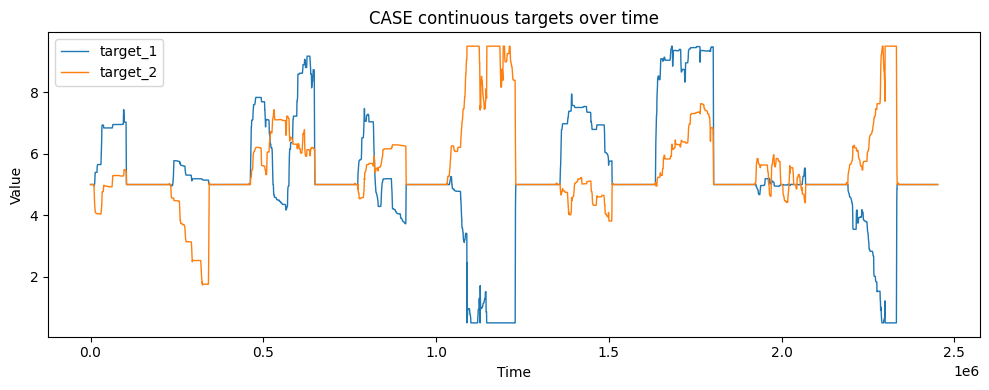

In [ ]:
if not case_tables:
    raise RuntimeError('No CASE annotation tables found after extraction.')

case_table, case_info = normalize_case_table(case_tables[0])
print('Using CASE table:', case_tables[0])
print('Detected columns:', case_info)
display(case_table.head())

plt.figure(figsize=(10, 4))
for c in case_table.columns:
    if c != 'time':
        plt.plot(case_table['time'], case_table[c], label=c, linewidth=1)
plt.title('CASE continuous targets over time')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
CASE_WINDOW = 128
CASE_STRIDE = 32
CASE_BATCH_SIZE = 32


def build_case_windows(df: pd.DataFrame, window=CASE_WINDOW, stride=CASE_STRIDE):
    feat_cols = [c for c in df.columns if c != 'time']
    x_list, y_list = [], []
    values = df[feat_cols].values.astype(np.float32)
    for start in range(0, max(len(df) - window + 1, 0), stride):
        seg = values[start:start + window]
        if len(seg) < window:
            continue
        x_list.append(seg.T)
        y_list.append(seg[-1])
    if not x_list:
        return np.empty((0, len(feat_cols), window), dtype=np.float32), np.empty((0, len(feat_cols)), dtype=np.float32)
    return np.stack(x_list), np.stack(y_list)


class CASESequenceDataset(Dataset):
    def __init__(self, table_df, window=CASE_WINDOW, stride=CASE_STRIDE):
        self.feature_cols = [c for c in table_df.columns if c != 'time']
        scaler = StandardScaler()
        scaled = scaler.fit_transform(table_df[self.feature_cols].values)
        work = pd.DataFrame(scaled, columns=self.feature_cols)
        work.insert(0, 'time', table_df['time'].values)
        self.x, self.y = build_case_windows(work, window=window, stride=stride)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return {
            'x_seq': torch.tensor(self.x[idx], dtype=torch.float32),
            'y_last': torch.tensor(self.y[idx], dtype=torch.float32),
        }


In [ ]:
case_ds = CASESequenceDataset(case_table, window=CASE_WINDOW, stride=CASE_STRIDE)
case_loader = DataLoader(case_ds, batch_size=CASE_BATCH_SIZE, shuffle=True, num_workers=0)

print('CASE dataset windows:', len(case_ds))
if len(case_ds) > 0:
    case_batch = next(iter(case_loader))
    print('CASE x_seq shape:', case_batch['x_seq'].shape)
    print('CASE y_last shape:', case_batch['y_last'].shape)
else:
    print('CASE windows could not be built. Try reducing CASE_WINDOW.')


CASE dataset windows: 1529
CASE x_seq shape: torch.Size([32, 2, 128])
CASE y_last shape: torch.Size([32, 2])


## Final notebook structure recap

- **EDA**
  - IEMOCAP: utterance-level categorical distribution and duration statistics.
  - MELD: dialogue-utterance categorical distribution and duration statistics.
  - CASE: continuous target trajectory inspection.

- **Mel Spectrogram & MFCC extraction**
  - Applied to **IEMOCAP** and **MELD** only.
  - Shared audio preprocessing code keeps the feature pipeline consistent.

- **Dataloaders**
  - **IEMOCAP** utterance loader for the main classifier.
  - **MELD** utterance loader for external evaluation and a **context loader** for temporal dialogue modeling.
  - **CASE** sequence loader for continuous emotion change over time.

  
